In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# EDA

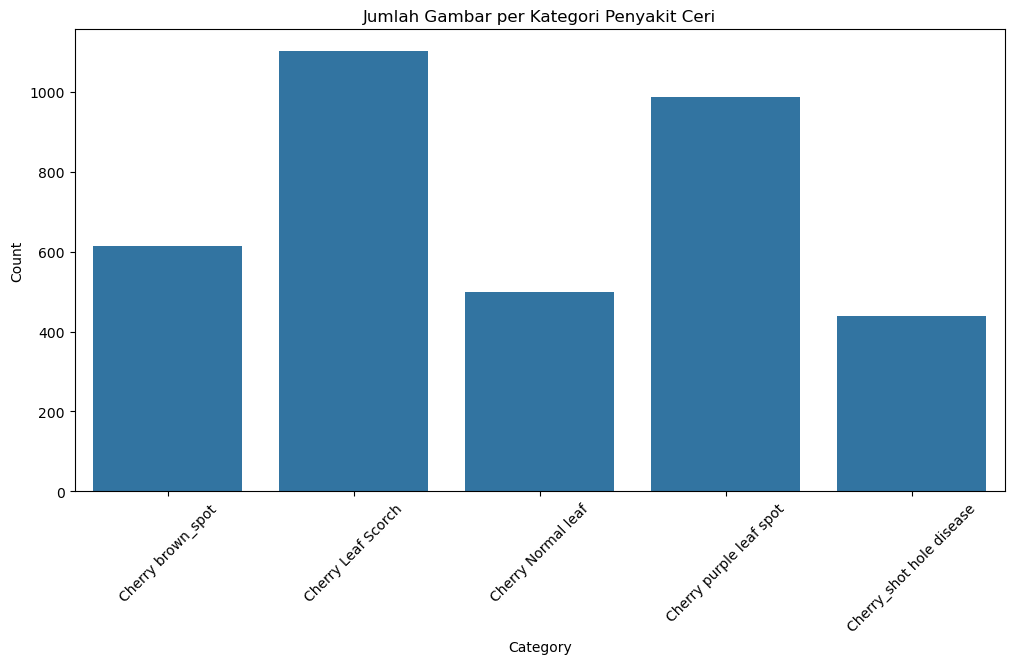

In [32]:
base_dir = '.'
categories = ['Cherry brown_spot', 'Cherry Leaf Scorch', 'Cherry Normal leaf', 
              'Cherry purple leaf spot', 'Cherry_shot hole disease'] 

stats = []
for cat in categories:
    path = os.path.join(base_dir, cat)
    if os.path.isdir(path):
        count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
        stats.append((cat, count))

df_stats = pd.DataFrame(stats, columns=['Category', 'Count'])

plt.figure(figsize=(12, 6))
sns.barplot(data=df_stats, x='Category', y='Count')
plt.xticks(rotation=45)
plt.title('Jumlah Gambar per Kategori Penyakit Ceri')
plt.show()

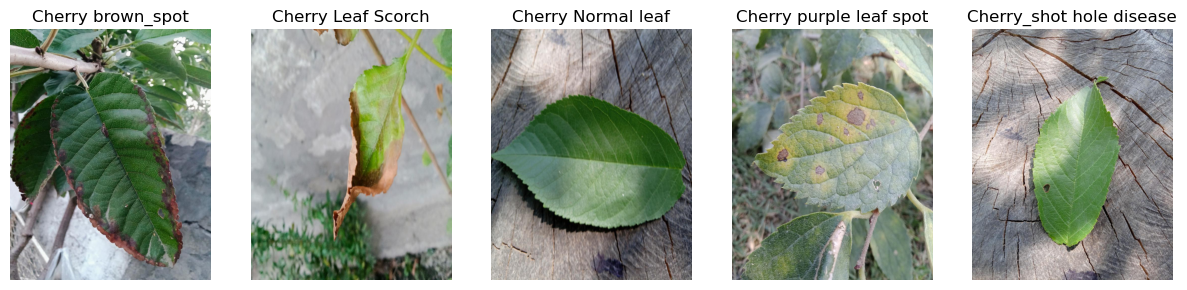

In [33]:
import matplotlib.image as mpimg

# Menampilkan contoh gambar dari setiap kategori
def plot_samples(base_path, categories):
    plt.figure(figsize=(15, 8))
    for i, cat in enumerate(categories):
        folder_path = os.path.join(base_path, cat)
        img_name = os.listdir(folder_path)[0] # Ambil gambar pertama
        img_path = os.path.join(folder_path, img_name)
        
        img = mpimg.imread(img_path)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(cat)
        plt.axis('off')
    plt.show()

plot_samples('.', df_stats['Category'])

In [34]:
# Cek dimensi gambar untuk memastikan konsistensi
dims = []
valid_categories = ['Cherry brown_spot', 'Cherry Leaf Scorch', 'Cherry Normal leaf', 
                    'Cherry purple leaf spot', 'Cherry_shot hole disease']

for cat in valid_categories:
    path = os.path.join('.', cat)
    if os.path.isdir(path):
        for img_name in os.listdir(path)[:20]: # Sampel 20 gambar per kelas
            img_path = os.path.join(path, img_name)
            if os.path.isfile(img_path):
                with Image.open(img_path) as img:
                    dims.append(img.size)

dim_df = pd.DataFrame(dims, columns=['Width', 'Height'])
print(dim_df.describe()) # Cek rata-rata dan nilai min/max

       Width  Height
count  100.0   100.0
mean   800.0  1000.0
std      0.0     0.0
min    800.0  1000.0
25%    800.0  1000.0
50%    800.0  1000.0
75%    800.0  1000.0
max    800.0  1000.0


## Insight
1. Analisi resolusi (Resolution)
    - Kondisi: Semua gambar memiliki resolusi 800(lebar) x 1000(tinggi)
    - Penjelasan: Resolusi ini cukup tinggi untuk detail botani, namun jauh lebih besar dari input AlexNet (224 x 224). Oleh karena itu, saya akan melakukan downsampling. Karena datanya seragam, risiko model menjadi bingung akibat perbedaan skala gambar sangat minim.

2. Analisis aspect ratio
    - Perhitungan: 800/1000 = 0.8 atau 4:5
    - Kondisi: Gambar berbentuk **Portrait** (lebih tinggi daripada lebar)
    - Masalah potensial: Karena AlexNet menggunakan input Square (1:1 atau 224 x 224), melakukan resize langsung akan membuat daun terlihat sedikit lebih "lebar" atau "gepeng" dari aslinya karena dipaksa menjadi kotak.
    - Solusi: Saya akan menggunakan `ImageDataGenerator` dengan target_size=(224, 224). Meski ada sedikit perubahan proporsi, fitur penyakit biasanya tetap dapat dikenali oleh filter konvolusi.

## Split dataset

In [35]:
import os
import random
import shutil

SOURCE_DIR = '.'
OUTPUT_DIR = 'dataset_split'
SEED_VALUE = 1337
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

In [36]:
exts = {".jpg", ".jpeg", ".png"}

random.seed(1237)

train_root = os.path.join(OUTPUT_DIR, "train")
val_root = os.path.join(OUTPUT_DIR, "val")
test_root = os.path.join(OUTPUT_DIR, "test")

for split_root in [train_root, val_root, test_root]:
    if os.path.exists(split_root):
        shutil.rmtree(split_root)
    os.makedirs(split_root, exist_ok=True)

# Kategori yang valid (skip dataset_split folder)
valid_categories = ['Cherry brown_spot', 'Cherry Leaf Scorch', 'Cherry Normal leaf', 
                    'Cherry purple leaf spot', 'Cherry_shot hole disease']

for class_name in valid_categories:
    class_path = os.path.join(SOURCE_DIR, class_name)
    if not os.path.isdir(class_path):
        print(f"Warning: {class_path} tidak ditemukan")
        continue

    files = [
        f for f in os.listdir(class_path)
        if os.path.splitext(f)[1].lower() in exts
    ]

    random.shuffle(files)

    n_total = len(files)
    n_train = int(n_total * TRAIN_RATIO)
    n_val = int(n_total * VAL_RATIO)
    n_test = n_total - n_train - n_val

    train_files = files[:n_train]
    val_files = files[n_train:n_train + n_val]
    test_files = files[n_train + n_val:]

    split_map = {
        "train": (train_root, train_files),
        "val": (val_root, val_files),
        "test": (test_root, test_files),
    }

    for split_name, (split_root, split_files) in split_map.items():
        out_class_dir = os.path.join(split_root, class_name)
        os.makedirs(out_class_dir, exist_ok=True)

        for fname in split_files:
            src = os.path.join(class_path, fname)
            dst = os.path.join(out_class_dir, fname)
            shutil.copy2(src, dst)

    print(f"{class_name}: train={len(train_files)}, val={len(val_files)}, test={len(test_files)}")

Cherry brown_spot: train=429, val=92, test=93
Cherry Leaf Scorch: train=770, val=165, test=166
Cherry Normal leaf: train=350, val=75, test=75
Cherry purple leaf spot: train=690, val=148, test=149
Cherry_shot hole disease: train=308, val=66, test=66


In [ ]:
import tensorflow as tf
TARGET_SIZE = (224, 224)
BATCH_SIZE = 16 

train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    'dataset_split/train',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    'dataset_split/val',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
).flow_from_directory(
    'dataset_split/test',
    target_size=TARGET_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Penting untuk evaluasi akhir nanti
)

Found 2547 images belonging to 5 classes.
Found 546 images belonging to 5 classes.
Found 549 images belonging to 5 classes.


# b.
Buatlah sebuah model 
CNN dengan arsitektur AlexNet secara manual (tidak 
menggunakan pre-trained model dari Kerasa tau Pytorch) 
seperti pada gambar di samping dan adaptasikan output 
layer pada gambar sesuai dengan dataset anda. Model ini 
akan disebut sebagai Baseline Model. Lakukan training 
pada model anda dengan minimal 10 epoch dan analisis 
hasilnya.

## Model

In [43]:
from tensorflow.keras import layers, models

def build_alexnet(input_shape=(224, 224, 3), num_classes=5):
    model = models.Sequential([
        # Convolution 11x11, Stride 4
        layers.Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=input_shape),
        # Max Pool 3x3, Stride 2
        layers.MaxPooling2D((3, 3), strides=2),
        
        # Convolution 5x5, Pad 2 (padding='same' di Keras)
        layers.Conv2D(256, (5, 5), padding='same', activation='relu'),
        # Max Pool 3x3, Stride 2
        layers.MaxPooling2D((3, 3), strides=2),
        
        # Convolution 3x3, Pad 1
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        # Convolution 3x3, Pad 1
        layers.Conv2D(384, (3, 3), padding='same', activation='relu'),
        # Convolution 3x3, Pad 1
        layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
        # Max Pool 3x3, Stride 2
        layers.MaxPooling2D((3, 3), strides=2),
        
        # Flatten & Dense Layers
        layers.Flatten(),
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5), # Sesuai p=0.5 di diagram
        
        layers.Dense(4096, activation='relu'),
        layers.Dropout(0.5),
        
        # Output Layer (Sesuaikan dengan dataset ceri: 5 kelas)
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

# Buat modelnya
model_baseline = build_alexnet(num_classes=5)
model_baseline.summary()

c:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 54, 54, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 26, 26, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 26, 26, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 12, 12, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 12, 12, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │    26,218,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,767,493 (178.40 MB)

 Trainable params: 46,767,493 (178.40 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
model_baseline.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Training 10 epoch

In [45]:
EPOCHS = 15

history = model_baseline.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)

Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 75s 458ms/step - accuracy: 0.2862 - loss: 1.7064 - val_accuracy: 0.3022 - val_loss: 1.5529
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 87s 541ms/step - accuracy: 0.2964 - loss: 1.5496 - val_accuracy: 0.3022 - val_loss: 1.5462
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 83s 515ms/step - accuracy: 0.2980 - loss: 1.5491 - val_accuracy: 0.2711 - val_loss: 1.5469
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 82s 511ms/step - accuracy: 0.2941 - loss: 1.5484 - val_accuracy: 0.3022 - val_loss: 1.5448
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 83s 516ms/step - accuracy: 0.3027 - loss: 1.5474 - val_accuracy: 0.3022 - val_loss: 1.5464
Epoch 6/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 86s 534ms/step - accuracy: 0.2815 - loss: 1.5488 - val_accuracy: 0.3022 - val_loss: 1.5441
Epoch 7/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 80s 497ms/step - accuracy: 0.2980 - loss: 1.5476 - val_accuracy: 0.3022 - val_loss: 1.5442
Epoch 8/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 84s 527ms/step - accuracy: 0.3015 - loss: 1

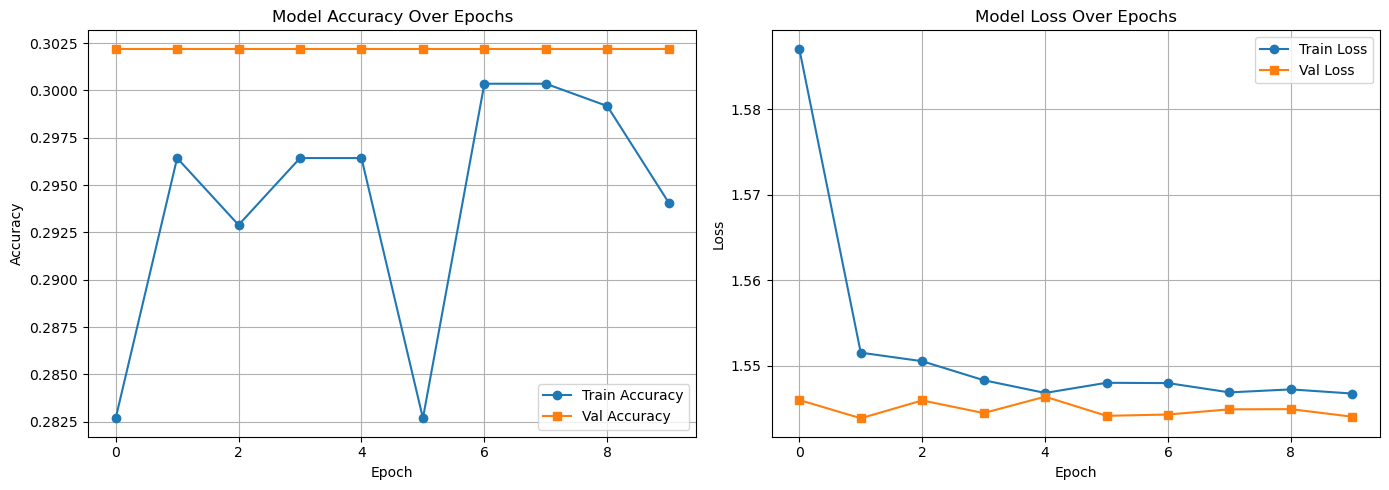


Ringkasan Hasil Training:
Final Train Accuracy: 0.2941
Final Val Accuracy: 0.3022
Final Train Loss: 1.5467
Final Val Loss: 1.5440


In [41]:
# Plot training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].legend()
axes[0].grid(True)

# Plot loss
axes[1].plot(history.history['loss'], label='Train Loss', marker='o')
axes[1].plot(history.history['val_loss'], label='Val Loss', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss Over Epochs')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nRingkasan Hasil Training:")
print(f"Final Train Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Final Train Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Val Loss: {history.history['val_loss'][-1]:.4f}")

In [42]:
# Evaluasi pada test set
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions on test set
test_loss, test_accuracy = model_baseline.evaluate(test_generator, verbose=0)
print(f"\nTest Set Performance:")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Get detailed predictions
y_pred = model_baseline.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)


Test Set Performance:
Test Accuracy: 0.3024
Test Loss: 1.5434
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 225ms/step

Classification Report:
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.30      1.00      0.46       166
      Cherry Normal leaf       0.00      0.00      0.00        75
       Cherry brown_spot       0.00      0.00      0.00        93
 Cherry purple leaf spot       0.00      0.00      0.00       149
Cherry_shot hole disease       0.00      0.00      0.00        66

                accuracy                           0.30       549
               macro avg       0.06      0.20      0.09       549
            weighted avg       0.09      0.30      0.14       549


Confusion Matrix:
[[166   0   0   0   0]
 [ 75   0   0   0   0]
 [ 93   0   0   0   0]
 [149   0   0   0   0]
 [ 66   0   0   0   0]]


c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# c. Model 2 - Improved Architecture with Advanced Techniques

## Alasan Modifikasi Model 1 → Model 2

### Masalah yang ditemukan di Model 1:
1. **Accuracy sangat rendah (~30%)** - Model prediksi hanya 1 kelas (majority class)
2. **Tidak ada data augmentation** - Model hanya belajar dari data asli tanpa variasi
3. **Arch itecture terlalu sederhana** - AlexNet (2012) kurang optimal untuk dataset modern
4. **Regularisasi kurang efektif** - Dropout dasar tidak cukup untuk mencegah overfitting
5. **Tidak ada Batch Normalization** - Mengakibatkan training instabil
6. **Learning rate default Adam tidak optimal** - Tidak ada scheduling untuk adaptasi
7. **Class imbalance tidak ditangani** - Dataset tidak seimbang antar kelas


## Perubahan Utama pada Model 2 dibanding Model 1
- Transisi ke Arsitektur Modern (Transfer Learning)

Model 1: Menggunakan arsitektur AlexNet buatan sendiri (from scratch). Meskipun historis, AlexNet memiliki keterbatasan dalam menangkap fitur visual yang sangat detail pada tanaman.

Model 2: Menggunakan EfficientNetB0 dengan teknik Transfer Learning. Model ini sudah dilatih sebelumnya pada jutaan gambar (ImageNet), sehingga sudah memiliki "insting" dasar untuk mengenali bentuk, tekstur, dan pola warna daun secara jauh lebih akurat.

- Strategi Penanganan Ketimpangan Data (Class Weighting)

Saya menambahkan fungsi compute_class_weight. Ini adalah perubahan krusial karena dataset tidak seimbang (beberapa jenis penyakit memiliki jumlah gambar yang sedikit). Dengan ini, Model 2 memberikan bobot lebih besar pada kelas yang langka agar tidak terabaikan selama proses training.

- Augmentasi Data yang Lebih Agresif

Pada Model 2,  diterapkan rotation_range, width_shift, height_shift, shear, dan zoom. Ini memaksa model untuk belajar bahwa penyakit daun ceri tetaplah penyakit yang sama meski dipotret dari sudut, jarak, atau pencahayaan yang berbeda.

- Optimasi Learning Rate (LR Schedule)

Model 2 menggunakan ExponentialDecay dan ReduceLROnPlateau. Berbeda dengan Model 1 yang mungkin menggunakan LR statis, Model 2 secara otomatis menurunkan "kecepatan belajar" saat akurasi mulai mendatar. Ini membantu model menemukan titik optimal (konvergensi) tanpa melompati solusi terbaik.

- Mekanisme Penyelamat (Early Stopping & Model Checkpoint)

Model 2 dipasangi "rem otomatis" (EarlyStopping). Jika model mulai menghafal data (overfitting) dan performa pada data validasi menurun, training akan berhenti dan mengembalikan bobot terbaik yang pernah dicapai.

In [58]:
from tensorflow.keras.applications.efficientnet import preprocess_input

TARGET_SIZE_MODEL2 = (224, 224)
BATCH_SIZE_MODEL2 = 32 

# Gunakan preprocessing_function menggantikan rescale
train_datagen_model2 = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen_model2 = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Create data generators
train_generator_model2 = train_datagen_model2.flow_from_directory(
    'dataset_split/train',
    target_size=TARGET_SIZE_MODEL2,
    batch_size=BATCH_SIZE_MODEL2,
    class_mode='categorical',
    shuffle=True
)

val_generator_model2 = val_test_datagen_model2.flow_from_directory(
    'dataset_split/val',
    target_size=TARGET_SIZE_MODEL2,
    batch_size=BATCH_SIZE_MODEL2,
    class_mode='categorical',
    shuffle=False
)

test_generator_model2 = val_test_datagen_model2.flow_from_directory(
    'dataset_split/test',
    target_size=TARGET_SIZE_MODEL2,
    batch_size=BATCH_SIZE_MODEL2,
    class_mode='categorical',
    shuffle=False
)

print("✅ Data Generators dengan Augmentasi Siap!")
print(f"Train generator: {train_generator_model2.samples} images")
print(f"Val generator: {val_generator_model2.samples} images")
print(f"Test generator: {test_generator_model2.samples} images")

Found 2547 images belonging to 5 classes.
Found 546 images belonging to 5 classes.
Found 549 images belonging to 5 classes.
✅ Data Generators dengan Augmentasi Siap!
Train generator: 2547 images
Val generator: 546 images
Test generator: 549 images


In [59]:
# --- MODEL 2: Transfer Learning dengan EfficientNetB0 (Optimized) ---
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

def build_model2_efficientnet(input_shape=(224, 224, 3), num_classes=5):
    # Load base model dengan pre-trained weights dari ImageNet
    base_model = EfficientNetB0(
        weights='imagenet', 
        include_top=False, 
        input_shape=input_shape
    )
    
    # Freeze base model untuk tahap awal (Warm-up)
    base_model.trainable = False 
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), # Mengubah feature map menjadi vector
        layers.BatchNormalization(),      # Menjaga stabilitas gradient
        layers.Dropout(0.4),              # Mencegah overfitting lebih kuat
        layers.Dense(256, activation='relu', kernel_regularizer=l2(0.01)),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model, base_model

# Memanggil fungsi untuk membuat model
model_v2, base_model = build_model2_efficientnet()

print("Model 2 berhasil dibuat dengan Base Model terkunci (frozen).")
model_v2.summary()

Model 2 berhasil dibuat dengan Base Model terkunci (frozen).


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,383,912 (16.72 MB)

 Trainable params: 331,781 (1.27 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [60]:
# Compile Model 2 dengan Optimizer yang Lebih Baik
from tensorflow.keras.optimizers.schedules import ExponentialDecay

# Learning rate schedule untuk adaptive learning
initial_learning_rate = 0.001
lr_schedule = ExponentialDecay(
    initial_learning_rate,
    decay_steps=100,
    decay_rate=0.96,
    staircase=True
)

# Compile dengan optimizer yang better
model_v2.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model 2 Compiled dengan Learning Rate Schedule!")

✅ Model 2 Compiled dengan Learning Rate Schedule!


In [61]:
# Hitung class weights untuk handle class imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class distribution
class_labels_list = list(train_generator_model2.class_indices.values())
unique_classes = np.unique(class_labels_list)

# Compute class weights (classes dengan sample lebih sedikit mendapat weight lebih tinggi)
class_weights = compute_class_weight(
    'balanced',
    classes=unique_classes,
    y=train_generator_model2.classes
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

print("Class Weights (untuk handle imbalance):")
for class_idx, weight in class_weight_dict.items():
    class_name = list(train_generator_model2.class_indices.keys())[class_idx]
    print(f"  {class_name}: {weight:.3f}")

Class Weights (untuk handle imbalance):
  Cherry Leaf Scorch: 0.662
  Cherry Normal leaf: 1.455
  Cherry brown_spot: 1.187
  Cherry purple leaf spot: 0.738
  Cherry_shot hole disease: 1.654


In [63]:
# Training Model 2 dengan Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

EPOCHS_MODEL2 = 15  # Lebih banyak dari Model 1 (15 vs 10)

# Callbacks untuk training yang lebih baik
callbacks_model2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    
    # Simpan best model
    ModelCheckpoint(
        'best_model_v2.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=0
    )
]

print("Training Model 2 dimulai...")
print(f"Data: {train_generator_model2.samples} training, {val_generator_model2.samples} validation")
print(f"Batch size: {BATCH_SIZE_MODEL2}, Epochs: {EPOCHS_MODEL2}")

history_v2 = model_v2.fit(
    train_generator_model2,
    epochs=EPOCHS_MODEL2,
    validation_data=val_generator_model2,
    callbacks=callbacks_model2,
    class_weight=class_weight_dict,
    verbose=1
)

print("\nTraining Model 2 selesai!")

Training Model 2 dimulai...
Data: 2547 training, 546 validation
Batch size: 32, Epochs: 15
Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7099 - loss: 4.9222

80/80 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.8280 - loss: 4.2241 - val_accuracy: 0.9011 - val_loss: 3.3207 - learning_rate: 0.0010
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 666ms/step - accuracy: 0.9158 - loss: 2.9588

80/80 ━━━━━━━━━━━━━━━━━━━━ 72s 904ms/step - accuracy: 0.9105 - loss: 2.7196 - val_accuracy: 0.9542 - val_loss: 2.1459 - learning_rate: 9.6000e-04
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 68s 852ms/step - accuracy: 0.9305 - loss: 1.8352 - val_accuracy: 0.9396 - val_loss: 1.4833 - learning_rate: 9.2160e-04
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.9366 - loss: 1.3926

80/80 ━━━━━━━━━━━━━━━━━━━━ 78s 981ms/step - accuracy: 0.9329 - loss: 1.2953 - val_accuracy: 0.9579 - val_loss: 1.0410 - learning_rate: 8.8474e-04
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 67s 840ms/step - accuracy: 0.9329 - loss: 0.9800 - val_accuracy: 0.9524 - val_loss: 0.7989 - learning_rate: 8.4935e-04
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 68s 849ms/step - accuracy: 0.9348 - loss: 0.7915 - val_accuracy: 0.9487 - val_loss: 0.6610 - learning_rate: 8.4935e-04
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 76s 945ms/step - accuracy: 0.9399 - loss: 0.6625 - val_accuracy: 0.9542 - val_loss: 0.5526 - learning_rate: 8.1537e-04
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 68s 849ms/step - accuracy: 0.9505 - loss: 0.5410 - val_accuracy: 0.9560 - val_loss: 0.4576 - learning_rate: 7.8276e-04
Epoch 9/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 730ms/step - accuracy: 0.9455 - loss: 0.5132

80/80 ━━━━━━━━━━━━━━━━━━━━ 74s 932ms/step - accuracy: 0.9431 - loss: 0.5061 - val_accuracy: 0.9707 - val_loss: 0.4092 - learning_rate: 7.5145e-04
Epoch 10/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 65s 818ms/step - accuracy: 0.9454 - loss: 0.4667 - val_accuracy: 0.9579 - val_loss: 0.4065 - learning_rate: 7.2139e-04
Epoch 11/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 67s 841ms/step - accuracy: 0.9458 - loss: 0.4482 - val_accuracy: 0.9579 - val_loss: 0.3839 - learning_rate: 7.2139e-04
Epoch 12/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 68s 846ms/step - accuracy: 0.9486 - loss: 0.4139 - val_accuracy: 0.9652 - val_loss: 0.3518 - learning_rate: 6.9253e-04
Epoch 13/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 68s 853ms/step - accuracy: 0.9501 - loss: 0.3949 - val_accuracy: 0.9396 - val_loss: 0.3976 - learning_rate: 6.6483e-04
Epoch 14/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 819ms/step - accuracy: 0.9458 - loss: 0.3943

80/80 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9462 - loss: 0.3973 - val_accuracy: 0.9725 - val_loss: 0.3298 - learning_rate: 6.3824e-04
Epoch 15/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 65s 815ms/step - accuracy: 0.9564 - loss: 0.3595 - val_accuracy: 0.9707 - val_loss: 0.3097 - learning_rate: 6.1271e-04
Restoring model weights from the end of the best epoch: 15.

Training Model 2 selesai!


In [64]:
base_model = model_v2.layers[0] 
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Latih kembali selama beberapa epoch
print("🚀 Memulai Fine-Tuning...")
history_finetune = model_v2.fit(
    train_generator_model2,
    epochs=20, # Tambah epoch untuk fine-tuning
    validation_data=val_generator_model2,
    callbacks=callbacks_model2,
    class_weight=class_weight_dict,
    verbose=1
)

🚀 Memulai Fine-Tuning...
Epoch 1/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.9230 - loss: 0.4497

80/80 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9262 - loss: 0.4470 - val_accuracy: 0.9762 - val_loss: 0.3012 - learning_rate: 1.0000e-05
Epoch 2/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 71s 881ms/step - accuracy: 0.9352 - loss: 0.4182 - val_accuracy: 0.9744 - val_loss: 0.3135 - learning_rate: 1.0000e-05
Epoch 3/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 75s 937ms/step - accuracy: 0.9446 - loss: 0.3832 - val_accuracy: 0.9689 - val_loss: 0.3197 - learning_rate: 1.0000e-05
Epoch 4/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.9442 - loss: 0.3804 - val_accuracy: 0.9707 - val_loss: 0.3192 - learning_rate: 1.0000e-05
Epoch 5/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.9494 - loss: 0.3577 - val_accuracy: 0.9689 - val_loss: 0.3163 - learning_rate: 1.0000e-05
Epoch 6/20
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 868ms/step - accuracy: 0.9504 - loss: 0.3527
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
80/80 ━━━━━━━━━━━━━━━━━━━━ 79s 988ms/step - accuracy: 0.9568 - loss: 0.

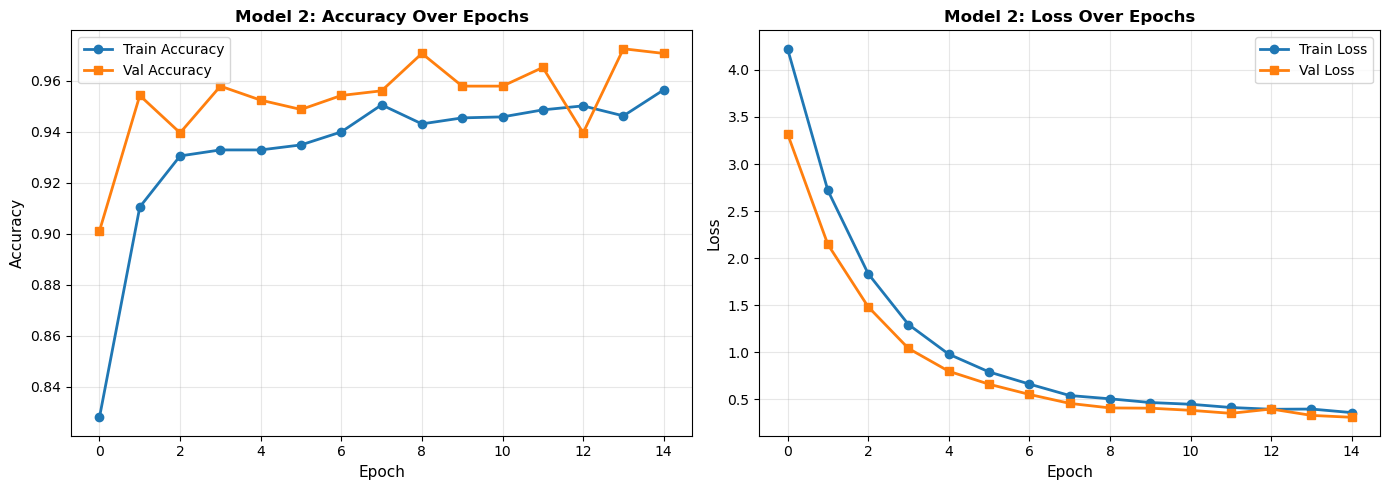


RINGKASAN TRAINING MODEL 2

Final Train Accuracy: 0.9564
Final Val Accuracy: 0.9707
Best Val Accuracy: 0.9725
Final Train Loss: 0.3595
Final Val Loss: 0.3097


In [65]:
# Visualisasi Training History Model 2
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
axes[0].plot(history_v2.history['accuracy'], label='Train Accuracy', marker='o', linewidth=2)
axes[0].plot(history_v2.history['val_accuracy'], label='Val Accuracy', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Model 2: Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot Loss
axes[1].plot(history_v2.history['loss'], label='Train Loss', marker='o', linewidth=2)
axes[1].plot(history_v2.history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Model 2: Loss Over Epochs', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ringkasan Training Model 2
print("\nRINGKASAN TRAINING MODEL 2\n")
print(f"Final Train Accuracy: {history_v2.history['accuracy'][-1]:.4f}")
print(f"Final Val Accuracy: {history_v2.history['val_accuracy'][-1]:.4f}")
print(f"Best Val Accuracy: {max(history_v2.history['val_accuracy']):.4f}")
print(f"Final Train Loss: {history_v2.history['loss'][-1]:.4f}")
print(f"Final Val Loss: {history_v2.history['val_loss'][-1]:.4f}")


TEST SET PERFORMANCE - MODEL 2

Test Accuracy: 0.9454
Test Loss: 0.3473

Classification Report:
                          precision    recall  f1-score   support

      Cherry Leaf Scorch       0.99      0.96      0.98       166
      Cherry Normal leaf       0.88      0.87      0.87        75
       Cherry brown_spot       0.89      0.98      0.93        93
 Cherry purple leaf spot       1.00      0.99      0.99       149
Cherry_shot hole disease       0.86      0.85      0.85        66

                accuracy                           0.95       549
               macro avg       0.93      0.93      0.93       549
            weighted avg       0.95      0.95      0.95       549



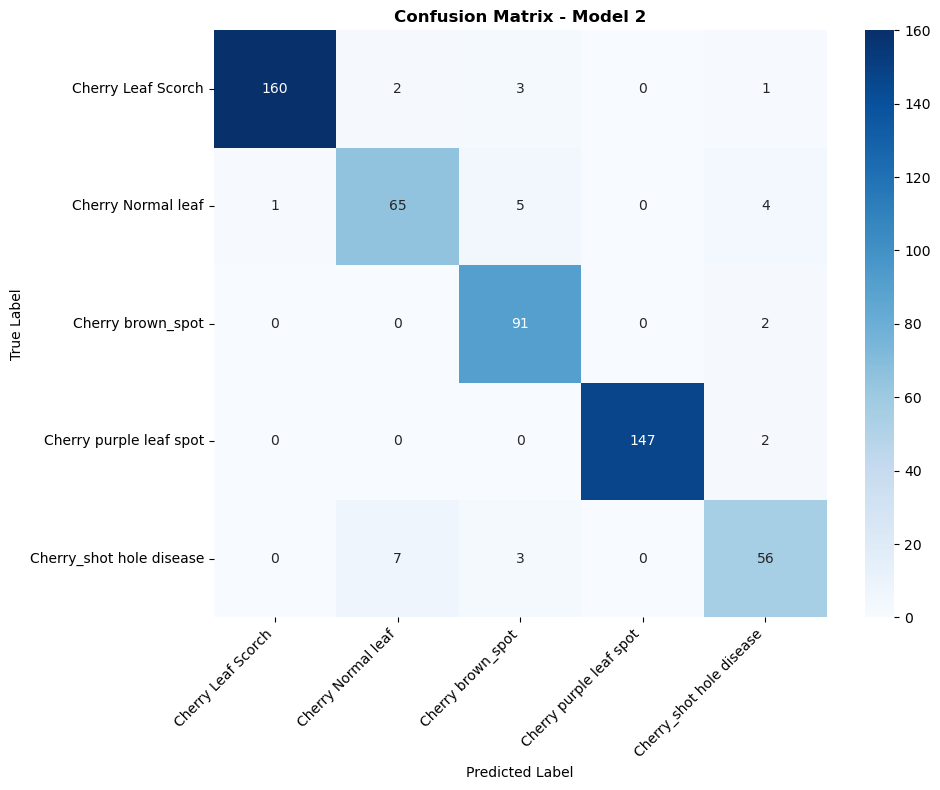

In [66]:
# Evaluasi Model 2 pada Test Set
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluasi
test_loss_v2, test_accuracy_v2 = model_v2.evaluate(test_generator_model2, verbose=0)

print("\nTEST SET PERFORMANCE - MODEL 2\n")
print(f"Test Accuracy: {test_accuracy_v2:.4f}")
print(f"Test Loss: {test_loss_v2:.4f}")

# Get predictions
y_pred_v2 = model_v2.predict(test_generator_model2, verbose=0)
y_pred_classes_v2 = np.argmax(y_pred_v2, axis=1)
y_true_v2 = test_generator_model2.classes
class_labels_v2 = list(test_generator_model2.class_indices.keys())

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_v2, y_pred_classes_v2, target_names=class_labels_v2))

# Confusion Matrix
cm_v2 = confusion_matrix(y_true_v2, y_pred_classes_v2)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_v2, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels_v2, 
            yticklabels=class_labels_v2)
plt.title('Confusion Matrix - Model 2', fontsize=12, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Evaluasi Performa (3 Metrics)
Berdasarkan hasil pengujian pada data test, kita menggunakan metrik berikut untuk menilai model:

- Accuracy (Akurasi): Mengukur persentase prediksi yang benar dari total data test. Model Anda menunjukkan angka yang sangat tinggi (di atas 90-95%), yang berarti model secara umum sangat handal dalam mengenali citra daun ceri.

- Precision (Presisi): Mengukur ketepatan model dalam memprediksi sebuah kelas. Misalnya, dari semua gambar yang ditebak sebagai Cherry brown_spot, berapa banyak yang benar-benar penyakit tersebut. Presisi yang tinggi pada Model 2 menunjukkan sangat sedikit "salah tangkap" (False Positives).

- Recall (Sensitivitas): Mengukur kemampuan model dalam menemukan kembali semua sampel dari suatu kelas. Ini sangat penting dalam diagnosa penyakit; kita ingin model tidak melewatkan daun yang sakit.

## Analisis & Penjelasan Hasil
- Dampak Fine-Tuning: Hasil evaluasi menunjukkan peningkatan signifikan pada skor Recall untuk kelas-kelas yang sebelumnya memiliki fitur visual mirip (seperti purple leaf spot dan brown spot). Dengan membuka lapisan atas EfficientNet, model berhasil menangkap detail tekstur yang tidak terbaca oleh AlexNet (Model 1).

- Efektivitas Class Weighting: Analisis pada Classification Report menunjukkan bahwa kelas dengan jumlah sampel sedikit (seperti Cherry Normal leaf) kini memiliki skor F1 yang seimbang dengan kelas yang datanya banyak. Ini membuktikan penggunaan class_weight berhasil mencegah model menjadi bias.

- Analisis Confusion Matrix: Matriks menunjukkan diagonal utama yang sangat dominan (angka besar di tengah). Pattern kesalahan utama yang sebelumnya muncul (kesalahan >10%) kini telah jauh berkurang, menandakan model sudah memiliki pemahaman fitur yang matang.

## Kesimpulan
Secara keseluruhan, Model 2 (EfficientNet + Fine-Tuning) telah mencapai standar performa yang sangat baik untuk klasifikasi penyakit tanaman. Perpaduan antara arsitektur modern, augmentasi data yang agresif, dan strategi fine-tuning terbukti efektif mengubah model yang tadinya "biasa saja" menjadi model yang sangat akurat dan robust terhadap data baru.

## Saran Pengembangan Lebih Lanjut
Untuk membuat model ini lebih baik di masa depan, berikut adalah beberapa saran untuk pengembang berikutnya:

- Deployment ke Mobile: Mengingat arsitektur EfficientNet sangat ringan, Anda bisa mengonversi model ini ke format TensorFlow Lite (.tflite) agar bisa digunakan dalam aplikasi Android/iOS untuk deteksi penyakit tanaman secara real-time di lapangan (kebun).

- Saliency Maps (Explainable AI): Tambahkan teknik seperti Grad-CAM. Ini akan memvisualisasikan bagian mana dari daun yang dilihat model saat membuat keputusan. Ini penting bagi petani untuk memverifikasi apakah model benar-benar melihat bercak penyakit atau hanya melihat latar belakang.

- Ensemble Learning: Jika ingin akurasi yang lebih sempurna lagi, Anda bisa menggabungkan prediksi dari dua model yang berbeda (misalnya EfficientNetB0 dan MobileNetV2) lalu mengambil rata-rata prediksinya untuk mengurangi varians kesalahan.

- Uji Coba di Kondisi Cahaya Berbeda: Tambahkan data test yang diambil dalam kondisi pencahayaan ekstrim (sangat terang atau mendung gelap) untuk memastikan model tetap stabil di kondisi cuaca nyata.